In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torchvision.models import ResNet50_Weights, ViT_B_16_Weights
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score,
                             recall_score, f1_score)
import time
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASS_NAMES = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
print(f"Device: {device}")

Device: cuda


In [2]:
# ImageNet normalisation — same as used during training for all three models
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder('augmented_dataset/test', transform=transform)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"Test set: {len(test_dataset)} images")
print(f"Classes : {test_dataset.classes}")

Test set: 962 images
Classes : ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


In [3]:
# --- Baseline CNN ---
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.conv1   = nn.Conv2d(3,  16, kernel_size=3, padding=1)
        self.conv2   = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3   = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool    = nn.MaxPool2d(2, 2)
        self.fc1     = nn.Linear(64 * 28 * 28, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2     = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)


# --- ResNet-50 ---
def build_resnet50():
    model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 4)
    )
    return model


# --- ViT-B/16 ---
def build_vit():
    model = models.vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    num_features = model.heads.head.in_features
    model.heads = nn.Sequential(
        nn.LayerNorm(num_features),
        nn.Linear(num_features, 256),
        nn.GELU(),
        nn.Dropout(0.3),
        nn.Linear(256, 4)
    )
    return model


print("Architectures defined.")

Architectures defined.


In [4]:
model_cnn = BaselineCNN().to(device)
model_cnn.load_state_dict(torch.load('baseline_cnn.pth', map_location=device))
model_cnn.eval()
print('✅ Baseline CNN loaded')

model_resnet = build_resnet50().to(device)
model_resnet.load_state_dict(torch.load('resnet50.pth', map_location=device))
model_resnet.eval()
print('✅ ResNet-50 loaded')

model_vit = build_vit().to(device)
model_vit.load_state_dict(torch.load('vit.pth', map_location=device))
model_vit.eval()
print('✅ ViT-B/16 loaded')

✅ Baseline CNN loaded
✅ ResNet-50 loaded
✅ ViT-B/16 loaded


In [5]:
def evaluate_model(model, loader, model_name):
    all_preds, all_labels = [], []
    start = time.time()

    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            preds  = model(images).argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    inf_time = time.time() - start

    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"  Inference time ({len(all_labels)} images): {inf_time:.2f}s")
    print(f"{'='*60}")
    print(classification_report(all_labels, all_preds,
                                target_names=CLASS_NAMES, digits=4))

    return np.array(all_labels), np.array(all_preds), inf_time


labels_cnn,    preds_cnn,    time_cnn    = evaluate_model(model_cnn,    test_loader, 'Baseline CNN')
labels_resnet, preds_resnet, time_resnet = evaluate_model(model_resnet, test_loader, 'ResNet-50')
labels_vit,    preds_vit,    time_vit    = evaluate_model(model_vit,    test_loader, 'ViT-B/16')


  Baseline CNN
  Inference time (962 images): 2.35s
                  precision    recall  f1-score   support

    MildDemented     0.9481    0.9481    0.9481       135
ModerateDemented     1.0000    1.0000    1.0000        11
     NonDemented     0.9337    0.9688    0.9509       480
VeryMildDemented     0.9528    0.9018    0.9266       336

        accuracy                         0.9428       962
       macro avg     0.9587    0.9547    0.9564       962
    weighted avg     0.9432    0.9428    0.9426       962


  ResNet-50
  Inference time (962 images): 3.10s
                  precision    recall  f1-score   support

    MildDemented     0.9692    0.9333    0.9509       135
ModerateDemented     1.0000    1.0000    1.0000        11
     NonDemented     0.9630    0.9771    0.9700       480
VeryMildDemented     0.9401    0.9345    0.9373       336

        accuracy                         0.9563       962
       macro avg     0.9681    0.9612    0.9646       962
    weighted avg     0

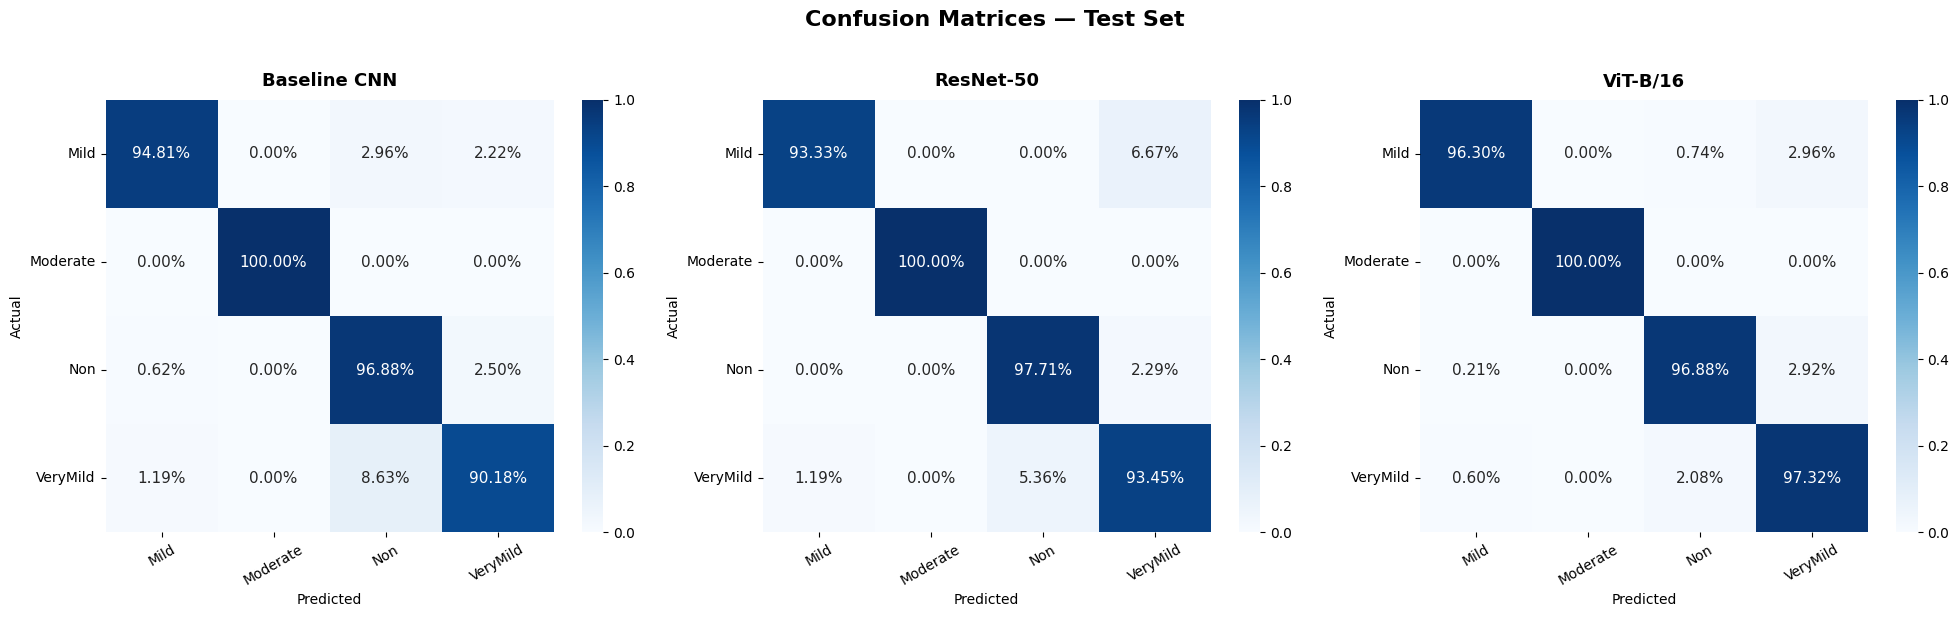

Saved: confusion_matrices.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrices — Test Set', fontsize=16, fontweight='bold', y=1.02)

models_data  = [
    ('Baseline CNN', labels_cnn,    preds_cnn),
    ('ResNet-50',    labels_resnet, preds_resnet),
    ('ViT-B/16',     labels_vit,    preds_vit),
]
short_names = ['Mild', 'Moderate', 'Non', 'VeryMild']

for ax, (name, labels, preds) in zip(axes, models_data):
    cm      = confusion_matrix(labels, preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=short_names, yticklabels=short_names,
                ax=ax, vmin=0, vmax=1, annot_kws={'size': 11})
    ax.set_title(name, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual',    fontsize=10)
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrices.png")

In [7]:
def get_metrics(labels, preds, model_name, inf_time):
    acc        = accuracy_score(labels, preds)
    prec_macro = precision_score(labels, preds, average='macro',  zero_division=0)
    rec_macro  = recall_score(  labels, preds, average='macro',  zero_division=0)
    f1_macro   = f1_score(      labels, preds, average='macro',  zero_division=0)
    rec_per    = recall_score(  labels, preds, average=None,     zero_division=0)
    f1_per     = f1_score(      labels, preds, average=None,     zero_division=0)
    return {
        'Model'             : model_name,
        'Accuracy'          : f"{acc:.4f}",
        'Precision (macro)' : f"{prec_macro:.4f}",
        'Recall (macro)'    : f"{rec_macro:.4f}",
        'F1 (macro)'        : f"{f1_macro:.4f}",
        'Recall VeryMild'   : f"{rec_per[3]:.4f}",
        'F1 VeryMild'       : f"{f1_per[3]:.4f}",
        'Inference (s)'     : f"{inf_time:.2f}",
    }

results = [
    get_metrics(labels_cnn,    preds_cnn,    'Baseline CNN', time_cnn),
    get_metrics(labels_resnet, preds_resnet, 'ResNet-50',    time_resnet),
    get_metrics(labels_vit,    preds_vit,    'ViT-B/16',     time_vit),
]

print('\n' + '='*95)
print('  FINAL COMPARISON TABLE — TEST SET EVALUATION')
print('='*95)

headers = list(results[0].keys())
col_w   = [16, 10, 20, 16, 12, 18, 13, 15]
print(''.join(h.ljust(w) for h, w in zip(headers, col_w)))
print('-' * 95)
for row in results:
    print(''.join(str(v).ljust(w) for v, w in zip(row.values(), col_w)))
print('='*95)
print('\nCritical metric: Recall on VeryMildDemented (minimise false negatives)')


  FINAL COMPARISON TABLE — TEST SET EVALUATION
Model           Accuracy  Precision (macro)   Recall (macro)  F1 (macro)  Recall VeryMild   F1 VeryMild  Inference (s)  
-----------------------------------------------------------------------------------------------
Baseline CNN    0.9428    0.9587              0.9547          0.9564      0.9018            0.9266       2.35           
ResNet-50       0.9563    0.9681              0.9612          0.9646      0.9345            0.9373       3.10           
ViT-B/16        0.9699    0.9771              0.9762          0.9766      0.9732            0.9604       8.67           

Critical metric: Recall on VeryMildDemented (minimise false negatives)


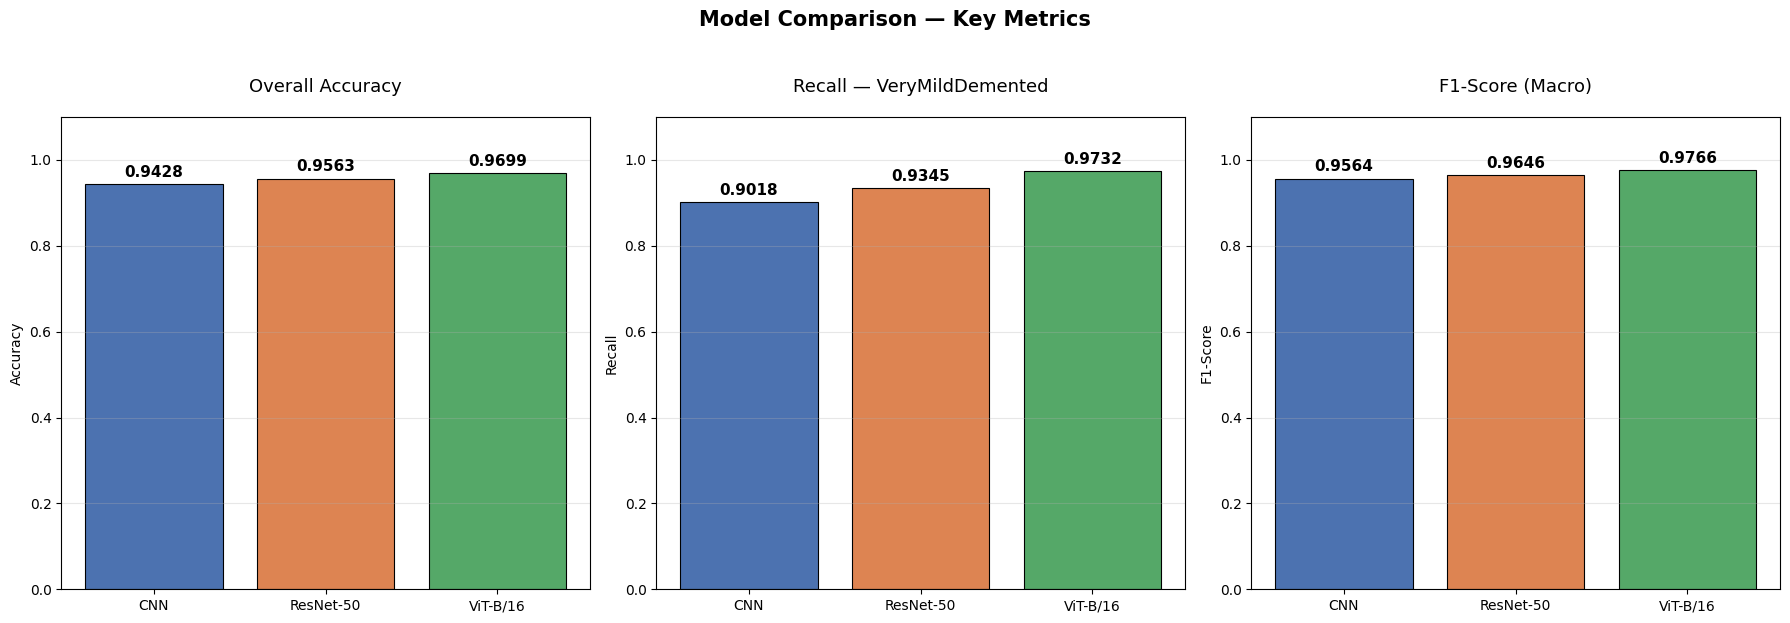

Saved: comparison_metrics.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Comparison — Key Metrics', fontsize=15, fontweight='bold', y=1.03)

model_names = ['CNN', 'ResNet-50', 'ViT-B/16']
colors      = ['#4C72B0', '#DD8452', '#55A868']

acc_vals = [
    accuracy_score(labels_cnn,    preds_cnn),
    accuracy_score(labels_resnet, preds_resnet),
    accuracy_score(labels_vit,    preds_vit),
]
rec_vmd = [
    recall_score(labels_cnn,    preds_cnn,    average=None, zero_division=0)[3],
    recall_score(labels_resnet, preds_resnet, average=None, zero_division=0)[3],
    recall_score(labels_vit,    preds_vit,    average=None, zero_division=0)[3],
]
f1_macro_vals = [
    f1_score(labels_cnn,    preds_cnn,    average='macro', zero_division=0),
    f1_score(labels_resnet, preds_resnet, average='macro', zero_division=0),
    f1_score(labels_vit,    preds_vit,    average='macro', zero_division=0),
]

for ax, values, title, ylabel in zip(
    axes,
    [acc_vals, rec_vmd, f1_macro_vals],
    ['Overall Accuracy', 'Recall — VeryMildDemented', 'F1-Score (Macro)'],
    ['Accuracy', 'Recall', 'F1-Score']
):
    bars = ax.bar(model_names, values, color=colors, edgecolor='black', linewidth=0.8)
    ax.set_title(title, fontsize=13, pad=18)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_metrics.png")

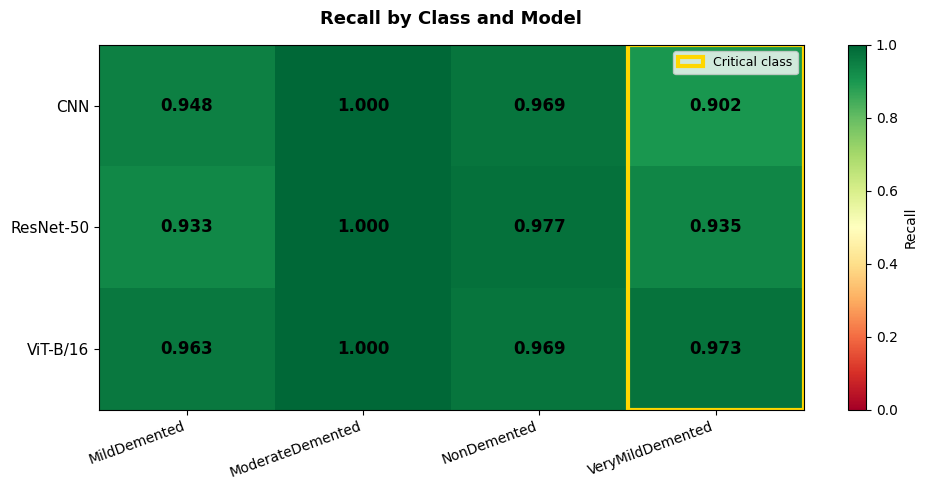

Saved: recall_heatmap.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

recall_matrix = np.array([
    recall_score(labels_cnn,    preds_cnn,    average=None, zero_division=0),
    recall_score(labels_resnet, preds_resnet, average=None, zero_division=0),
    recall_score(labels_vit,    preds_vit,    average=None, zero_division=0),
])

im = ax.imshow(recall_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Recall')

ax.set_xticks(range(4))
ax.set_xticklabels(CLASS_NAMES, rotation=20, ha='right', fontsize=10)
ax.set_yticks(range(3))
ax.set_yticklabels(['CNN', 'ResNet-50', 'ViT-B/16'], fontsize=11)
ax.set_title('Recall by Class and Model', fontsize=13, fontweight='bold', pad=15)

for i in range(3):
    for j in range(4):
        color = 'black' if recall_matrix[i, j] > 0.5 else 'white'
        ax.text(j, i, f'{recall_matrix[i, j]:.3f}',
                ha='center', va='center', fontsize=12, fontweight='bold', color=color)

ax.add_patch(plt.Rectangle((2.5, -0.5), 1, 3,
                             fill=False, edgecolor='gold', linewidth=3,
                             label='Critical class'))
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('recall_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: recall_heatmap.png")

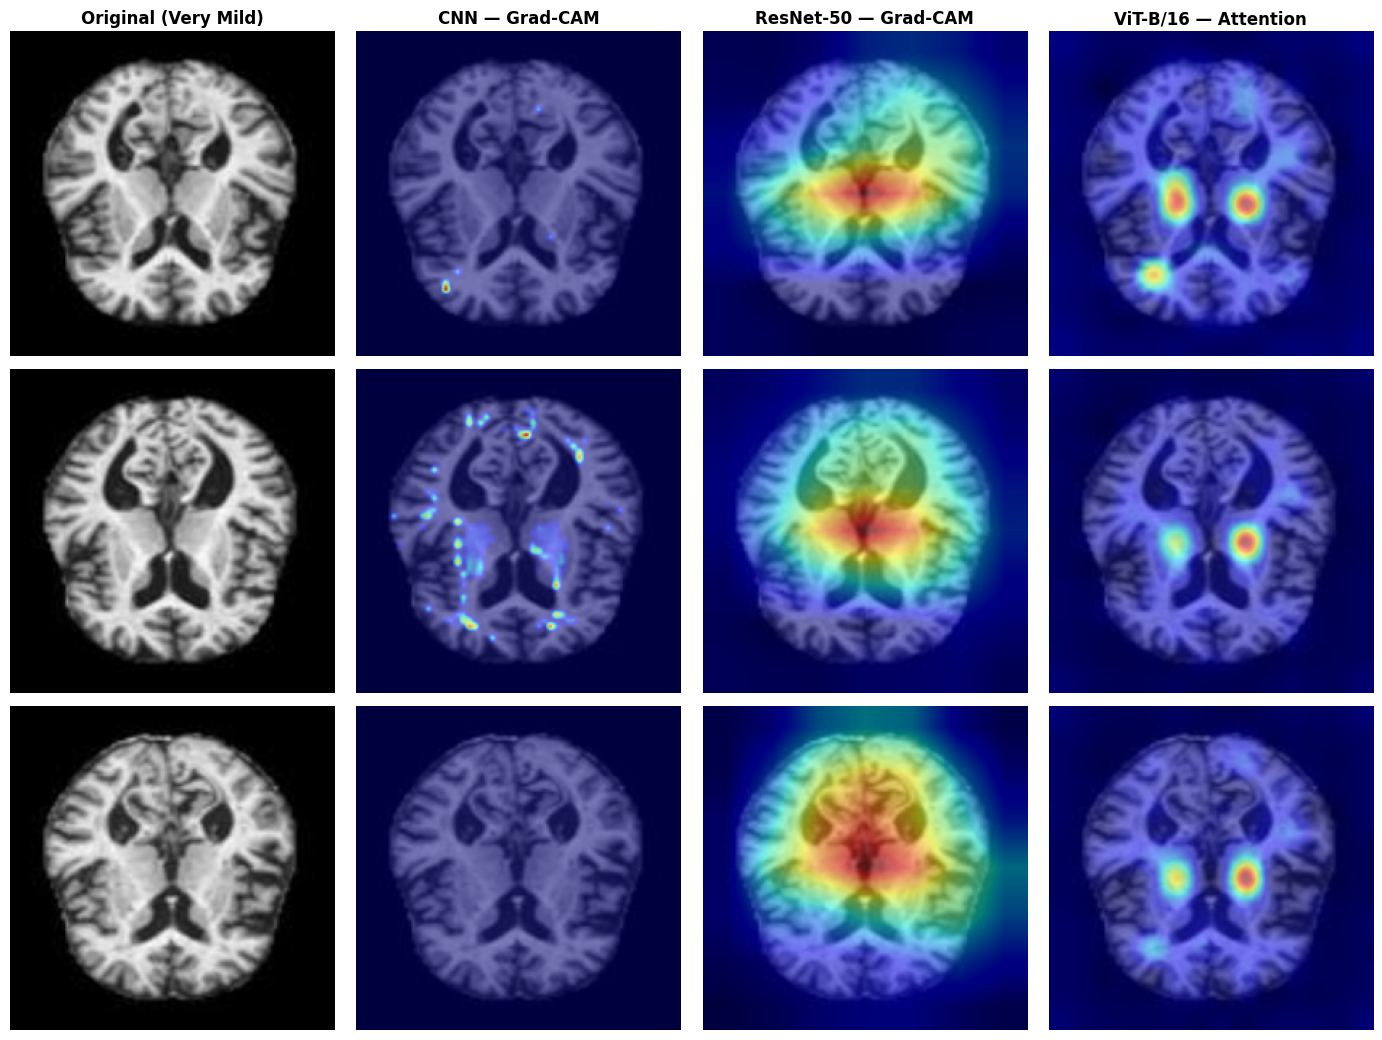

Saved interpretability.png


In [14]:
#  Interpretability: Grad-CAM (CNN, ResNet) + Attention Rollout (ViT)

import torch.nn.functional as F
from PIL import Image

# Grad-CAM for convolutional models
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self._save_act)
        target_layer.register_full_backward_hook(self._save_grad)

    def _save_act(self, module, inp, out):
        self.activations = out.detach()

    def _save_grad(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def __call__(self, x, class_idx):
        self.model.zero_grad()
        out = self.model(x)
        out[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=(224, 224), mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

# Attention rollout for ViT (recursion-safe)
def vit_attention_rollout(model, x):

    captured = []
    def pre_hook(module, args):
        captured.append(args[0].detach())
    handles = [blk.self_attention.register_forward_pre_hook(pre_hook)
               for blk in model.encoder.layers]
    with torch.no_grad():
        _ = model(x)
    for h in handles:
        h.remove()

    attn_weights = []
    with torch.no_grad():
        for blk, inp in zip(model.encoder.layers, captured):
            _, w = blk.self_attention(inp, inp, inp,
                                      need_weights=True, average_attn_weights=True)
            attn_weights.append(w)

    device = x.device
    n = attn_weights[0].size(-1)
    result = torch.eye(n, device=device)
    for w in attn_weights:
        a = w[0] + torch.eye(n, device=device)
        a = a / a.sum(dim=-1, keepdim=True)
        result = a @ result

    mask = result[0, 1:].reshape(14, 14).cpu().numpy()
    mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)
    mask = np.array(Image.fromarray((mask * 255).astype('uint8')).resize((224, 224)))
    return mask / 255.0

# De-normalise tensor to viewable image
def denorm(t):
    mean = np.array([0.485, 0.456, 0.406]); std = np.array([0.229, 0.224, 0.225])
    img = t.squeeze().permute(1, 2, 0).cpu().numpy()
    return np.clip(img * std + mean, 0, 1)

# A few VeryMild test images (class index 3)
vmd_idx = CLASS_NAMES.index('VeryMildDemented')
sample_indices = [i for i, (_, y) in enumerate(test_dataset.samples) if y == vmd_idx][:3]

cam_cnn    = GradCAM(model_cnn,    model_cnn.conv3)
cam_resnet = GradCAM(model_resnet, model_resnet.layer4[-1])

n = len(sample_indices)
fig, axes = plt.subplots(n, 4, figsize=(14, 3.5 * n))
if n == 1: axes = axes[None, :]
col_titles = ['Original (Very Mild)', 'CNN — Grad-CAM',
              'ResNet-50 — Grad-CAM', 'ViT-B/16 — Attention']

for r, idx in enumerate(sample_indices):
    img_t, _ = test_dataset[idx]
    x = img_t.unsqueeze(0).to(device)
    base = denorm(img_t)

    heat_cnn    = cam_cnn(x.clone().requires_grad_(True),    vmd_idx)
    heat_resnet = cam_resnet(x.clone().requires_grad_(True), vmd_idx)
    heat_vit    = vit_attention_rollout(model_vit, x)

    axes[r, 0].imshow(base)
    for c, heat in zip([1, 2, 3], [heat_cnn, heat_resnet, heat_vit]):
        axes[r, c].imshow(base)
        axes[r, c].imshow(heat, cmap='jet', alpha=0.5)
    for c in range(4):
        axes[r, c].axis('off')
        if r == 0: axes[r, c].set_title(col_titles[c], fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('interpretability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved interpretability.png')